In [16]:
import jax 
import jax.numpy as jnp
from jax import jit
import matplotlib.pyplot as plt
JAX_ENABLE_X64=True

In [17]:
N = 200
L = 100.0
dx = L / N
u = jnp.zeros(N)
dt = 0.01

## Kuramoto_shivashinsky Equation 1D 
# $\frac{\partial u}{\partial t} = -u_x - u_{xxxx} - u\frac{\partial u}{\partial x}$


In [18]:
@jit
def KS_JAX(u):

    kappa = 2.0 * jnp.pi*jnp.fft.rfftfreq(N, d=dx)
    c =  kappa**2 - kappa**4
    int_fac = jnp.exp(c * dt) 

    # Linear Treatmnet
    uhat = jnp.fft.rfft(u)
    linear_term = int_fac * uhat

    # Non-Linear Treatment
    int_fac_NonLinear = jnp.where(
        c==0,
        dt,
        (int_fac - 1)/c
    )
    alias_mask = ( kappa < 2/3*jnp.max(kappa) )
    f = -0.5*u**2
    fhat = jnp.fft.rfft(f)
    fhat_masked = alias_mask*fhat
    fhat_x = (1j)*kappa*fhat_masked
    nonlinear_term = int_fac_NonLinear*fhat_x

    # Compute next time value
    uhat_next = linear_term + nonlinear_term
    u_next = jnp.fft.irfft(uhat_next, N)

    return u_next
    
    

In [21]:
x = jnp.linspace(0.0, L, N, endpoint=False)
u = jnp.sin(16*jnp.pi*x/L)

trj = [u,]
for i in range(24000):
    u = KS_JAX(u)
    trj.append(u)

trj = jnp.stack(trj)

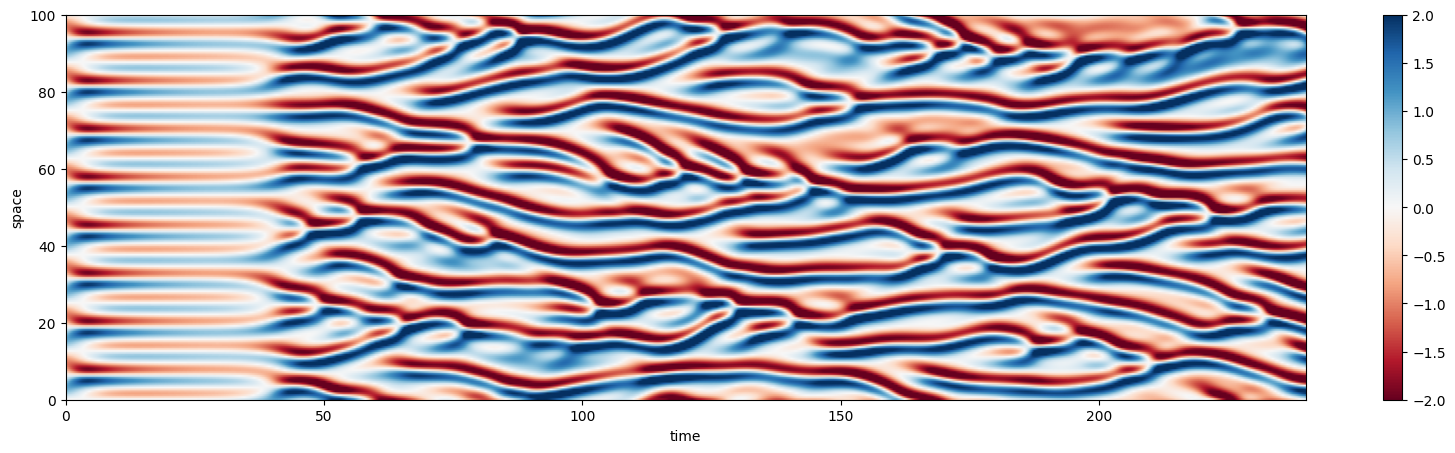

In [22]:
plt.figure(figsize=(20,5))
plt.imshow(trj.T, cmap="RdBu", aspect="auto", origin="lower", extent=(0, trj.shape[0]*dt, 0 ,100), vmin=-2, vmax=2, )
plt.colorbar()
plt.xlabel("time")
plt.ylabel("space")
plt.show()

In [23]:
@jit
def KS_RKETD2(u):

    kappa = 2.0 * jnp.pi*jnp.fft.rfftfreq(N, d=dx)
    c =  kappa**2 - kappa**4
    int_fac = jnp.exp(c * dt) 

    # Linear Treatmnet
    uhat = jnp.fft.rfft(u)
    linear_term = int_fac * uhat

    # Non-Linear Treatment
    int_fac_NonLinear = jnp.where(
        c==0,
        dt,
        (int_fac - 1)/c
    )
    int_fac_NonLinear_step1 = jnp.where(
        c==0,
        dt,
        (int_fac - 1 - dt*c) / (dt*c**2)
    )
    
    alias_mask = ( kappa < 2/3*jnp.max(kappa) )
    f = -0.5*u**2
    fhat = jnp.fft.rfft(f)
    fhat_masked = alias_mask*fhat
    fhat_x = (1j)*kappa*fhat_masked
    nonlinear_term_an = int_fac_NonLinear*fhat_x

    # Compute next time value
    uhat_next = linear_term + nonlinear_term_an
    u_next = jnp.fft.irfft(uhat_next, N)

    # Next step terms
    f_plus_1 = -0.5*u_next**2
    f_plus_1_hat = jnp.fft.rfft(f_plus_1)
    f_plus_1_hat_masked = alias_mask * f_plus_1_hat
    der_x_f_plus_1_hat_masked = (1j)*kappa*f_plus_1_hat_masked
    
    u_next_final_hat = uhat_next + (der_x_f_plus_1_hat_masked - fhat_x)*int_fac_NonLinear_step1
    u_next_final = jnp.fft.irfft(u_next_final_hat)

    return u_next_final
    
    

In [24]:
x = jnp.linspace(0.0, L, N, endpoint=False)
u = jnp.sin(16*jnp.pi*x/L)

trj = [u,]
for i in range(24000):
    u = KS_RKETD2(u)
    trj.append(u)

trj = jnp.stack(trj)

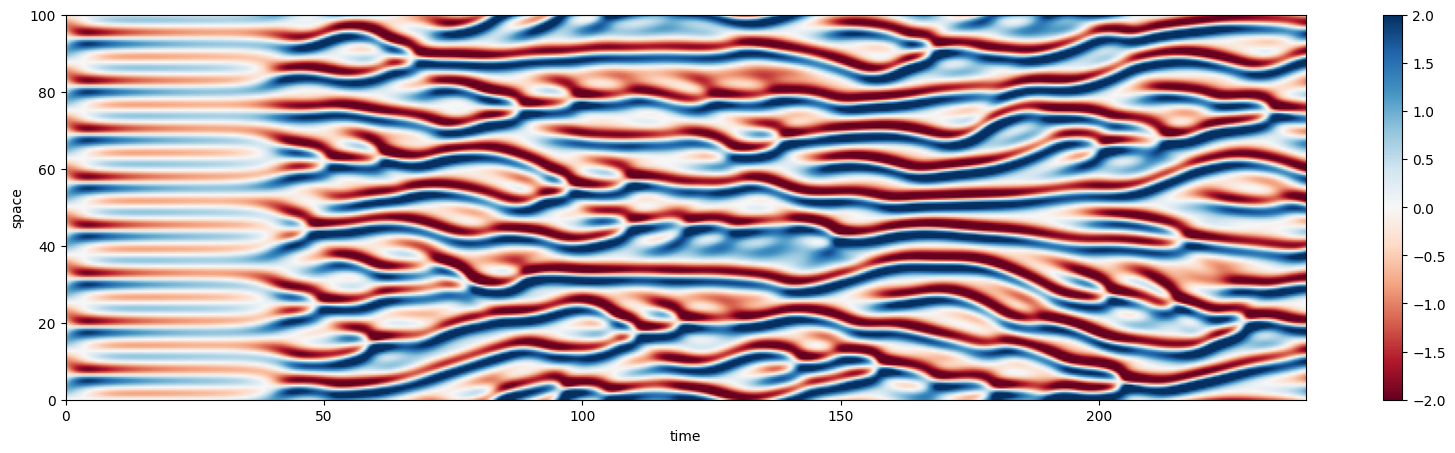

In [25]:
plt.figure(figsize=(20,5))
plt.imshow(trj.T, cmap="RdBu", aspect="auto", origin="lower", extent=(0, trj.shape[0]*dt, 0 ,100), vmin=-2, vmax=2, )
plt.colorbar()
plt.xlabel("time")
plt.ylabel("space")
plt.show()